In [43]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from sklearn.datasets import load_iris
from sklearn.datasets import load_wine
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Code for Metric Score Calculations

In [15]:
def full_cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    #pairwise distance matrix
    D = cdist(X, X)

    # computation of centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # to avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # to exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [16]:
def cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            #inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

# Iris Dataset

In [17]:
iris = load_iris()

df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

display(df_iris)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [18]:
X = df_iris.drop('target', axis=1)
y = df_iris['target']

labelencoder_X = LabelEncoder()
labelencoder_X.fit(y)
y = labelencoder_X.transform(y)

In [26]:
k_values = [i for i in range(2,7)]
results_iris = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pred = kmeans.fit_predict(X)

    std_sil = silhouette_score(X, labels_pred)
    full_cw_sil = full_cw_sil_score(X, labels_pred)
    cw_sil = cw_sil_score(X, labels_pred)

    ari = adjusted_rand_score(y, labels_pred)
    nmi = normalized_mutual_info_score(y, labels_pred)

    results_iris.append({
        "k": k,
        "standard_silhouette": std_sil,
        "full_cw_sil": full_cw_sil,
        "cw_sil": cw_sil,
        "ARI": ari,
        "NMI": nmi
    })

In [27]:
df_results_iris = pd.DataFrame(results_iris)
display(df_results_iris)

,k,standard_silhouette,full_cw_sil,cw_sil,ARI,NMI
0,2,0.681046,0.719484,0.718162,0.539922,0.656519
1,3,0.552819,0.579872,0.594635,0.730238,0.758176
2,4,0.498051,0.530005,0.545500,0.649818,0.721920
3,5,0.491240,0.519024,0.530531,0.612454,0.696392
4,6,0.364834,0.392609,0.415035,0.447534,0.637954


In [28]:
k_std = df_results_iris.loc[df_results_iris["standard_silhouette"].idxmax(), "k"]
k_full_cw = df_results_iris.loc[df_results_iris["full_cw_sil"].idxmax(), "k"]
k_cw = df_results_iris.loc[df_results_iris["cw_sil"].idxmax(), "k"]

print("Standard-silhouette selected k:", k_std)
print("Full-CW-silhouette selected k:", k_full_cw)
print("CW-silhouette selected k:", k_cw)

Standard-silhouette selected k: 2
Full-CW-silhouette selected k: 2
CW-silhouette selected k: 2


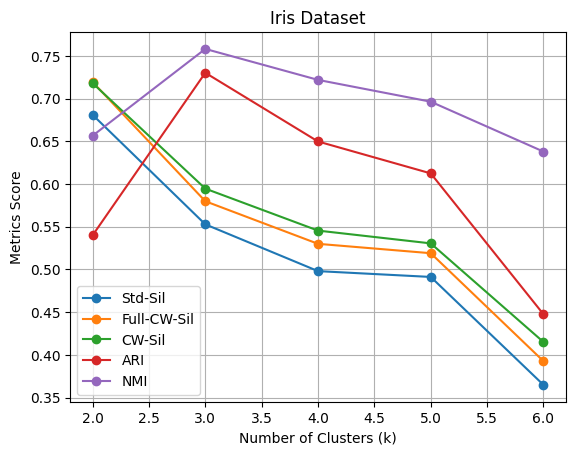

In [42]:
plt.figure()

plt.plot(k_values, df_results_iris["standard_silhouette"], marker='o', label="Std-Sil")
plt.plot(k_values, df_results_iris["full_cw_sil"], marker='o', label="Full-CW-Sil")
plt.plot(k_values, df_results_iris["cw_sil"], marker='o', label="CW-Sil")
plt.plot(k_values, df_results_iris["ARI"], marker='o', label="ARI")
plt.plot(k_values, df_results_iris["NMI"], marker='o', label="NMI")

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Metrics Score')
plt.title('Iris Dataset')
plt.legend()
plt.grid()

plt.show()

# Seeds Dataset

In [35]:
columns = ["area", "perimeter", "compactness", "length of kernel", "width of kernel", "asymmetry coefficient", "length of kernel groove", "target"]
df_seeds = pd.read_csv(r"seeds\seeds_dataset.tsv", sep="\t", header=None, names=columns)
display(df_seeds)

,area,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [36]:
X = df_seeds.drop("target", axis=1)
y = df_seeds["target"]

In [37]:
k_values = [i for i in range(2,7)]
results_seeds = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pred = kmeans.fit_predict(X)

    std_sil = silhouette_score(X, labels_pred)
    full_cw_sil = full_cw_sil_score(X, labels_pred)
    cw_sil = cw_sil_score(X, labels_pred)

    ari = adjusted_rand_score(y, labels_pred)
    nmi = normalized_mutual_info_score(y, labels_pred)

    results_seeds.append({
        "k": k,
        "standard_silhouette": std_sil,
        "full_cw_sil": full_cw_sil,
        "cw_sil": cw_sil,
        "ARI": ari,
        "NMI": nmi
    })

In [38]:
df_results_seeds = pd.DataFrame(results_seeds)
display(df_results_seeds)

,k,standard_silhouette,full_cw_sil,cw_sil,ARI,NMI
0,2,0.518287,0.560331,0.560128,0.468323,0.536073
1,3,0.471934,0.520968,0.534215,0.716620,0.694925
2,4,0.395360,0.440898,0.460047,0.605647,0.647932
3,5,0.367368,0.415329,0.436290,0.559996,0.621458
4,6,0.360839,0.390942,0.417859,0.453370,0.595800


In [39]:
k_std = df_results_seeds.loc[df_results_seeds["standard_silhouette"].idxmax(), "k"]
k_full_cw = df_results_seeds.loc[df_results_seeds["full_cw_sil"].idxmax(), "k"]
k_cw = df_results_seeds.loc[df_results_seeds["cw_sil"].idxmax(), "k"]

print("Standard-silhouette selected k:", k_std)
print("Full-CW-silhouette selected k:", k_full_cw)
print("CW-silhouette selected k:", k_cw)

Standard-silhouette selected k: 2
Full-CW-silhouette selected k: 2
CW-silhouette selected k: 2


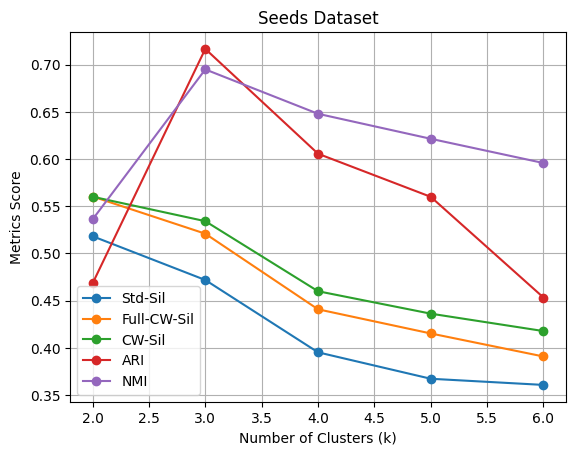

In [41]:
plt.figure()

plt.plot(k_values, df_results_seeds["standard_silhouette"], marker='o', label="Std-Sil")
plt.plot(k_values, df_results_seeds["full_cw_sil"], marker='o', label="Full-CW-Sil")
plt.plot(k_values, df_results_seeds["cw_sil"], marker='o', label="CW-Sil")
plt.plot(k_values, df_results_seeds["ARI"], marker='o', label="ARI")
plt.plot(k_values, df_results_seeds["NMI"], marker='o', label="NMI")

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Metrics Score')
plt.title('Seeds Dataset')
plt.legend()
plt.grid()

plt.show()

# Wine Dataset

In [44]:
wine = load_wine()

df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target

display(df_wine)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [46]:
X = df_wine.drop('target', axis=1)
y = df_wine['target']

labelencoder_y = LabelEncoder()
y = labelencoder_y.fit_transform(y)

In [47]:
k_values = [i for i in range(2,7)]
results_wine = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pred = kmeans.fit_predict(X)

    std_sil = silhouette_score(X, labels_pred)
    full_cw_sil = full_cw_sil_score(X, labels_pred)
    cw_sil = cw_sil_score(X, labels_pred)

    ari = adjusted_rand_score(y, labels_pred)
    nmi = normalized_mutual_info_score(y, labels_pred)

    results_wine.append({
        "k": k,
        "standard_silhouette": std_sil,
        "full_cw_sil": full_cw_sil,
        "cw_sil": cw_sil,
        "ARI": ari,
        "NMI": nmi
    })

In [48]:
df_results_wine = pd.DataFrame(results_wine)
display(df_results_wine)

,k,standard_silhouette,full_cw_sil,cw_sil,ARI,NMI
0,2,0.656854,0.709015,0.713098,0.369408,0.425919
1,3,0.571138,0.630298,0.635817,0.371114,0.428757
2,4,0.562032,0.622146,0.630288,0.303443,0.388433
3,5,0.548999,0.605505,0.608751,0.311588,0.410993
4,6,0.565641,0.624189,0.624684,0.290902,0.399739


In [49]:
k_std = df_results_wine.loc[df_results_wine["standard_silhouette"].idxmax(), "k"]
k_full_cw = df_results_wine.loc[df_results_wine["full_cw_sil"].idxmax(), "k"]
k_cw = df_results_wine.loc[df_results_wine["cw_sil"].idxmax(), "k"]

print("Standard-silhouette selected k:", k_std)
print("Full-CW-silhouette selected k:", k_full_cw)
print("CW-silhouette selected k:", k_cw)

Standard-silhouette selected k: 2
Full-CW-silhouette selected k: 2
CW-silhouette selected k: 2


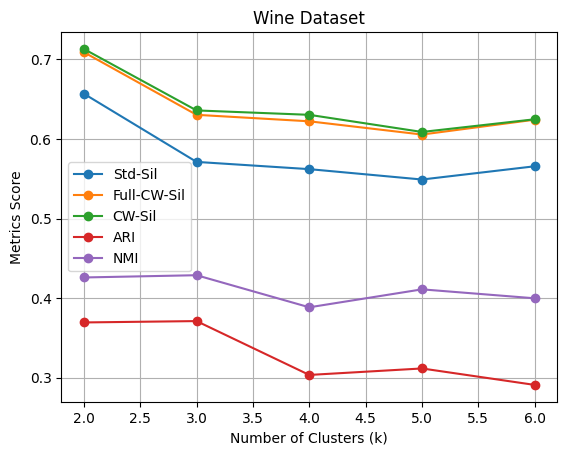

In [50]:
plt.figure()

plt.plot(k_values, df_results_wine["standard_silhouette"], marker='o', label="Std-Sil")
plt.plot(k_values, df_results_wine["full_cw_sil"], marker='o', label="Full-CW-Sil")
plt.plot(k_values, df_results_wine["cw_sil"], marker='o', label="CW-Sil")
plt.plot(k_values, df_results_wine["ARI"], marker='o', label="ARI")
plt.plot(k_values, df_results_wine["NMI"], marker='o', label="NMI")

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Metrics Score')
plt.title('Wine Dataset')
plt.legend()
plt.grid()

plt.show()